In [ ]:
!pip uninstall -y bitsandbytes -q
!pip install -U bitsandbytes -q
!pip install -q -U transformers accelerate datasets peft auto-gptq optimum

import bitsandbytes as bnb
print("bitsandbytes version:", bnb.__version__)
print("CUDA available to bnb:", bnb.cuda_setup.main.get_compute_capabilities() if hasattr(bnb, "cuda_setup") else "check manually")

In [1]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

In [2]:
import torch, time, copy, gc
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import load_dataset

MODEL_NAME = "Qwen/Qwen2.5-0.5B"
DEVICE = "cuda"
torch.manual_seed(42)

In [3]:
wikitext = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
full_text = "\n\n".join(wikitext["text"])

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encodings = tokenizer(full_text, return_tensors="pt")

# Small fast subset for the sensitivity sweep (Phase 3)
SWEEP_TOKENS = 1000
sweep_ids = encodings.input_ids[:, :SWEEP_TOKENS].to(DEVICE)

# Larger subset for final benchmark table (Phase 6) — still capped for speed
FULL_EVAL_TOKENS = 8000
eval_ids = encodings.input_ids[:, :FULL_EVAL_TOKENS].to(DEVICE)

Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors


In [4]:
def evaluate_model(model, input_ids, stride=512, label=""):
    model.eval()
    max_len = model.config.max_position_embeddings if hasattr(model.config, "max_position_embeddings") else 2048
    nlls, n_tokens = [], 0

    torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()

    with torch.no_grad():
        for i in range(0, input_ids.size(1), stride):
            begin, end = i, min(i + stride, input_ids.size(1))
            chunk = input_ids[:, begin:end]
            if chunk.size(1) < 2:
                continue
            out = model(chunk, labels=chunk)
            nlls.append(out.loss * chunk.size(1))
            n_tokens += chunk.size(1)

    elapsed = time.perf_counter() - start
    ppl = torch.exp(torch.stack(nlls).sum() / n_tokens).item()
    peak_mem_mb = torch.cuda.max_memory_allocated() / 1e6
    ms_per_token = (elapsed / n_tokens) * 1000

    print(f"[{label}] PPL: {ppl:.3f} | Latency: {ms_per_token:.3f} ms/token | Peak Mem: {peak_mem_mb:.1f} MB")
    return {"label": label, "ppl": ppl, "ms_per_token": ms_per_token, "peak_mem_mb": peak_mem_mb}

results = []

In [5]:
model_fp16 = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(DEVICE)
results.append(evaluate_model(model_fp16, eval_ids, label="FP16 Baseline"))
del model_fp16; gc.collect(); torch.cuda.empty_cache()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[FP16 Baseline] PPL: 20.203 | Latency: 0.169 ms/token | Peak Mem: 1953.0 MB


In [ ]:
!pip install -q -U bitsandbytes>=0.46.1

In [6]:
from transformers.utils import is_bitsandbytes_available
print("Transformers sees bitsandbytes:", is_bitsandbytes_available())

Transformers sees bitsandbytes: True


In [7]:
bnb_int8 = BitsAndBytesConfig(load_in_8bit=True)
model_int8 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_int8,
    torch_dtype=torch.float16,   # matches bnb's compute dtype
    device_map={"": 0},          # force single-GPU placement
)
results.append(evaluate_model(model_int8, eval_ids, label="Uniform PTQ INT8"))
del model_int8; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[Uniform PTQ INT8] PPL: 20.302 | Latency: 0.387 ms/token | Peak Mem: 1588.3 MB


In [8]:
bnb_int4 = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)
model_int4 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_int4,
    torch_dtype=torch.float16,
    device_map={"": 0},   # <-- force single-GPU placement (cuda:0)
)
results.append(evaluate_model(model_int4, eval_ids, label="Uniform PTQ INT4"))
del model_int4; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[Uniform PTQ INT4] PPL: 22.940 | Latency: 0.130 ms/token | Peak Mem: 1431.5 MB


In [9]:
import bitsandbytes as bnb
import torch.nn as nn

def replace_with_bnb_layer(model, key_substrings, mode="int4"):
    """Replace matching nn.Linear layers with REAL bnb quantized layers (not simulated)."""
    for parent_name, parent in model.named_modules():
        for child_name, child in list(parent.named_children()):
            full_name = f"{parent_name}.{child_name}" if parent_name else child_name
            if isinstance(child, nn.Linear) and any(k in full_name for k in key_substrings):
                has_bias = child.bias is not None
                if mode == "int4":
                    new_layer = bnb.nn.Linear4bit(
                        child.in_features, child.out_features,
                        bias=has_bias, compute_dtype=torch.float16, quant_type="nf4",
                    )
                elif mode == "int8":
                    new_layer = bnb.nn.Linear8bitLt(
                        child.in_features, child.out_features,
                        bias=has_bias, has_fp16_weights=False,
                    )
                new_layer.weight.data = child.weight.data.clone()
                if has_bias:
                    new_layer.bias.data = child.bias.data.clone()
                setattr(parent, child_name, new_layer)
    return model.to(DEVICE)  # .to(DEVICE) triggers the actual quantization

In [10]:
# Identify module-type groups by name pattern (works for Qwen2/Llama-style architectures)
ATTN_KEYS = ["q_proj", "k_proj", "v_proj", "o_proj"]
FFN_KEYS  = ["gate_proj", "up_proj", "down_proj"]

def quantize_selected_linears(model, key_substrings, bits=4):
    import torch.nn as nn
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(k in name for k in key_substrings):
            with torch.no_grad():
                w = module.weight.data
                qmin, qmax = -(2**(bits-1)), 2**(bits-1) - 1
                # per-channel scale: one scale per output row, not one for the whole matrix
                scale = w.abs().amax(dim=1, keepdim=True) / qmax
                scale = scale.clamp(min=1e-8)  # avoid div-by-zero on all-zero rows
                w_q = torch.clamp((w / scale).round(), qmin, qmax) * scale
                module.weight.data = w_q.to(w.dtype)
    return model

sensitivity_results = {}
for group_name, keys in [("Attention (q/k/v/o)", ATTN_KEYS), ("FFN (gate/up/down)", FFN_KEYS)]:
    model_probe = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
    model_probe = replace_with_bnb_layer(model_probe, keys, mode="int4")
    r = evaluate_model(model_probe, sweep_ids, label=f"Sensitivity: {group_name}")
    sensitivity_results[group_name] = r["ppl"]
    del model_probe; gc.collect(); torch.cuda.empty_cache()

model_probe = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(DEVICE)
base_sweep_ppl = evaluate_model(model_probe, sweep_ids, label="Sweep Baseline (FP16)")["ppl"]
del model_probe; gc.collect(); torch.cuda.empty_cache()

for g, ppl in sensitivity_results.items():
    print(f"{g}: ΔPPL = {ppl - base_sweep_ppl:.4f}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[Sensitivity: Attention (q/k/v/o)] PPL: 16.488 | Latency: 0.114 ms/token | Peak Mem: 1843.2 MB


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[Sensitivity: FFN (gate/up/down)] PPL: 17.762 | Latency: 0.123 ms/token | Peak Mem: 1446.7 MB


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[Sweep Baseline (FP16)] PPL: 16.159 | Latency: 0.081 ms/token | Peak Mem: 1916.4 MB
Attention (q/k/v/o): ΔPPL = 0.3290
FFN (gate/up/down): ΔPPL = 1.6038


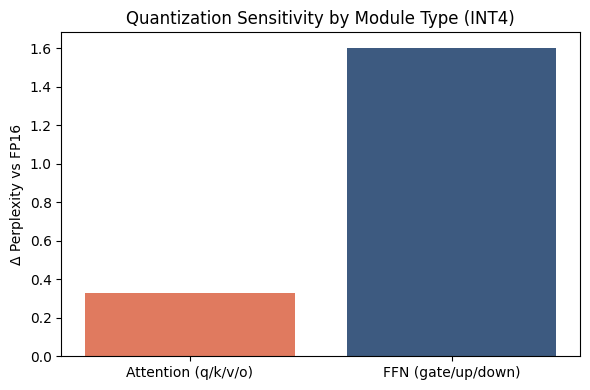

In [11]:
groups = list(sensitivity_results.keys())
deltas = [sensitivity_results[g] - base_sweep_ppl for g in groups]

plt.figure(figsize=(6,4))
plt.bar(groups, deltas, color=["#e07a5f", "#3d5a80"])
plt.ylabel("Δ Perplexity vs FP16")
plt.title("Quantization Sensitivity by Module Type (INT4)")
plt.tight_layout()
plt.savefig("sensitivity_chart.png", dpi=150)
plt.show()

In [12]:
def build_mixed_model():
    m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
    m = replace_with_bnb_layer(m, ATTN_KEYS, mode="int4")  # robust group, aggressive
    m = replace_with_bnb_layer(m, FFN_KEYS, mode="int8")   # sensitive group, conservative
    return m

model_mixed = build_mixed_model()
results.append(evaluate_model(model_mixed, eval_ids, label="Mixed PTQ (sensitivity-aware, real bnb)"))
del model_mixed; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[Mixed PTQ (sensitivity-aware, real bnb)] PPL: 21.336 | Latency: 0.150 ms/token | Peak Mem: 1572.6 MB


In [14]:
!pip uninstall -y torchao -q

In [15]:
import warnings
import logging

# Suppress bnb's repeated "inputs will be cast from torch.float32 to float16" warning
warnings.filterwarnings("ignore", message=".*inputs will be cast from torch.float32 to float16.*")

# bnb also emits this via its own logger in some versions — silence that path too
logging.getLogger("bitsandbytes").setLevel(logging.ERROR)

from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_qat = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
model_qat = replace_with_bnb_layer(model_qat, ATTN_KEYS, mode="int4")  # frozen, robust group
model_qat = replace_with_bnb_layer(model_qat, FFN_KEYS, mode="int8")   # THIS is what LoRA must repair
model_qat = prepare_model_for_kbit_training(model_qat)  # required for training on top of bnb layers

lora_cfg = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=FFN_KEYS,  # adapters on the group that is now genuinely degraded
    task_type="CAUSAL_LM",
)
model_qat = get_peft_model(model_qat, lora_cfg)
model_qat.print_trainable_parameters()

train_text = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:2%]")
train_ids = tokenizer("\n\n".join(train_text["text"]), return_tensors="pt").input_ids[:, :4000].to(DEVICE)

optimizer = torch.optim.AdamW(model_qat.parameters(), lr=2e-4)
model_qat.train()
STEPS, STRIDE = 20, 256
for step in range(STEPS):
    i = (step * STRIDE) % (train_ids.size(1) - STRIDE)
    chunk = train_ids[:, i:i+STRIDE]
    out = model_qat(chunk, labels=chunk)
    out.loss.backward()
    optimizer.step(); optimizer.zero_grad()
    if step % 5 == 0:
        with torch.no_grad():
            eval_ppl = evaluate_model(model_qat, sweep_ids, label=f"  [checkpoint step {step}]")["ppl"]
        model_qat.train()

results.append(evaluate_model(model_qat, eval_ids, label="Mixed PTQ + Targeted QLoRA"))
import pandas as pd
df = pd.DataFrame(results)
df.to_csv("final_benchmark_results.csv", index=False)
df

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 6,635,520 || all params: 500,668,288 || trainable%: 1.3253
[  [checkpoint step 0]] PPL: 16.465 | Latency: 0.207 ms/token | Peak Mem: 4039.5 MB
[  [checkpoint step 5]] PPL: 15.926 | Latency: 0.185 ms/token | Peak Mem: 4039.8 MB
[  [checkpoint step 10]] PPL: 15.936 | Latency: 0.179 ms/token | Peak Mem: 4040.9 MB
[  [checkpoint step 15]] PPL: 15.600 | Latency: 0.182 ms/token | Peak Mem: 4041.9 MB
[Mixed PTQ + Targeted QLoRA] PPL: 20.365 | Latency: 0.214 ms/token | Peak Mem: 4069.7 MB


,label,ppl,ms_per_token,peak_mem_mb
0,FP16 Baseline,20.202599,0.169197,1952.971264
1,Uniform PTQ INT8,20.301954,0.387090,1588.267520
2,Uniform PTQ INT4,22.940100,0.130411,1431.489024
3,"Mixed PTQ (sensitivity-aware, real bnb)",21.335831,0.149631,1572.580864
4,Mixed PTQ + Targeted QLoRA,20.365360,0.213934,4069.676544
